# Titanic Dataset (Problema de Regressão Logística)

Ciência de Dados e Analytics - Reitoria UPE

Equipe:
 - *Johnny Cleiton*
 - *Joss Timoteo*


Link do dataset: https://www.kaggle.com/datasets/yasserh/titanic-dataset?resource=download

Objetivo: prever se um passageiro sobreviveu ou não. Variável principal `survived`:
* 0 = não sobreviveu
* 1 = sobreviveu

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
print(df['Survived'].value_counts())

Survived
0    549
1    342
Name: count, dtype: int64


## Limpeza e Tratamento básico

1. Removendo colunas que não serão usadas (`Name`, `Ticket` e `Cabin`)
2. Converter variáveis categóricas para esquema binário
3. Tratar valores faltantes

In [ ]:
# 1
df = df.drop(["Name", "Ticket", "Cabin"], axis=1)

In [ ]:
# 2
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df["Embarked"] = df["Embarked"].map({"S": 0, "C": 1, "Q": 2})

In [ ]:
# 3
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

## Separar dados e dividir entre treino e teste

In [ ]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)

## Treinar o modelo usando Regressão Logística

In [ ]:
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# previsões
y_pred = modelo.predict(X_test)

In [ ]:
# teste rápido de previsão
print(y_pred[:10])

[0 0 0 1 1 1 1 0 1 1]


## Avaliar o modelo mostrando a acurácia

In [ ]:
print("Acurácia:", accuracy_score(y_test, y_pred))

Acurácia: 0.8059701492537313


Com cerca de 80% de acerto e consequentemente 20% de erros

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84        78
           1       0.79      0.73      0.76        56

    accuracy                           0.81       134
   macro avg       0.80      0.80      0.80       134
weighted avg       0.81      0.81      0.80       134



## Visualizações

In [ ]:
print(confusion_matrix(y_test, y_pred))

[[67 11]
 [15 41]]


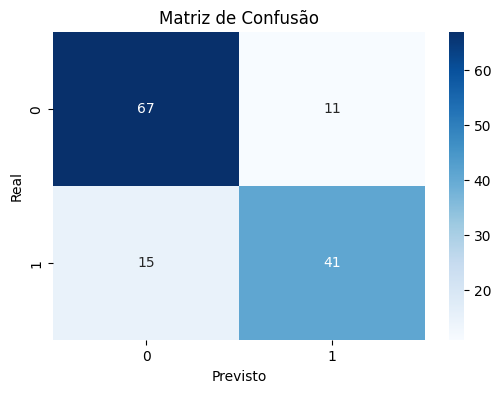

In [ ]:
# matriz de confusão visual
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

Gráfico que mostra quantas vezes o modelo previu cada classe

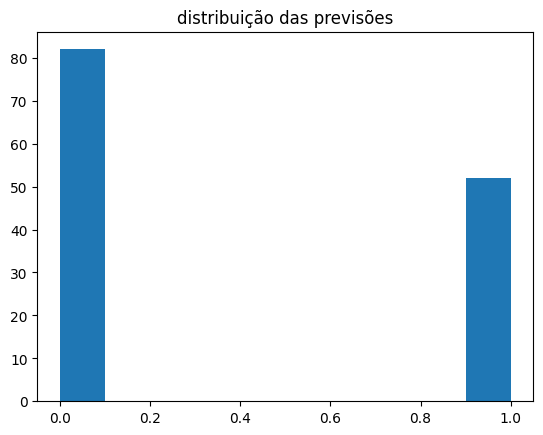

In [ ]:
plt.hist(y_pred)
plt.title("distribuição das previsões")
plt.show()

Pela analise do gráfico, o modelo está prevendo mais pessoas mortas (0) do que vivas (1).